To Do:

Start with image instead of density also add image coordinates.
add 3 coordinate axis 

In [33]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO
from numpyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.interpolate import RegularGridInterpolator


# Define the density function
def rho(x, y, z, e, p, q, rho0, s, a, b):
    #eps = 1e-12
    #r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    m = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / p)**(2 - e) + (jnp.abs(z) / q)**(2 - e)))**(1 / (2 - e)) 
    #m = jnp.maximum(m, eps)
    den = rho0 / ((m / s)**a * (1 + (m / s))**(b - a))
    return den / (p * q)


# Define the model
def model(x, y, z, rho_obs=None):
    #eps = 1e-12
    r = jnp.sqrt(x**2 + y**2 + z**2)
    #r = jnp.maximum(r,eps)
    
    # GP parameters for p(r)
    sigma_p = numpyro.param("sigma_p", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_p = numpyro.param("length_scale_p", jnp.array(0.5), constraint=dist.constraints.positive)
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r, diag=1e-5, mean=1.0)  
    p_sampled = numpyro.sample("p", gp_p.numpyro_dist())
    p_sampled = jax.nn.sigmoid(p)

    #interpolator = RegularGridInterpolator((r,), p_sampled, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    #p_sampled = interpolator(r)

    # Constant parameters
    q = 0.8
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 1.0
    b = 2.0

    # Compute the density
    density = rho(x, y, z, e, p_sampled, q, rho0, s, a, b)

    # Observation model
    numpyro.sample("rho_obs", dist.Normal(density, 0.1), obs=rho_obs)


# Use AutoGuide for variational inference
guide = AutoNormal(model)

# Optimizer and inference
optim = Adam(0.01)
svi = SVI(model, guide, optim, Trace_ELBO(10))

# Example usage
# Example input data (replace with actual data)
size = 3000
ex = 5
x = jnp.linspace(0.1, ex, size)  
y = jnp.linspace(0.1, ex, size)
z = jnp.linspace(0.1, ex, size)

# Create a 3D grid
#x, y, z = jnp.meshgrid(x_range, y_range, z_range, indexing="ij")
#x = x.flatten()
#y = y.flatten()
#z = z.flatten()
def p_sigmoid(x,y,z):
    r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    p = jax.nn.sigmoid(r)
    return p, r
p, r = p_sigmoid(x,y,z)

# Set the random key for reproducibility
key = jax.random.PRNGKey(42)

rho_obs = rho(x, y, z, 0., p, 0.8, 1.0, 1.0, 1.0, 2.0)

# Noise parameters
noise_mean = 0.0  # Mean of the noise
noise_std = 0.1   # Standard deviation of the noise

# Generate Gaussian noise
#noise = noise_mean + noise_std * jax.random.normal(key, shape=rho_obs.shape)

rho_obs = rho_obs #+noise



This breaks if we have input data that is 0 in x,y and z. rho_obs goes to infinity which leads to a ValueError: Normal distribution got invalid loc parameter.

If we add a term that prevents m from being zero we get RuntimeError: Cannot find valid initial parameters. Please check your model again.

If we use an observation that is not 0 it runs and we get results.
In this case if we increase the number of points we again get RuntimeError: Cannot find valid initial parameters. Please check your model again.


swapped from rho 3d grid using meshgrid to just calculationg rho over r, works alot better.

Still confused how we would want to translate rho(r) to a 3d density distribution

One problem that i see is that the modelparameters do not have that much impact on rho(r) so even if we have a good fit for rho(r) this doesnt correspond to a good fit in rho(x,y,z)



In [34]:

results = svi.run(jax.random.PRNGKey(42), 1000, x, y, z, rho_obs=rho_obs)

100%|██████████| 1000/1000 [06:21<00:00,  2.62it/s, init loss: 208234608.0000, avg. loss [951-1000]: 63163.7132] 


In [35]:
results.params

{'length_scale_p': Array(0.16328092, dtype=float32),
 'p_auto_loc': Array([-0.61080366, -0.5820686 , -0.5609709 , ...,  0.17547923,
         0.21727064,  0.2628283 ], dtype=float32),
 'p_auto_scale': Array([0.01404598, 0.01651204, 0.01360736, ..., 0.01319708, 0.03154597,
        0.02321646], dtype=float32),
 'sigma_p': Array(0.90133905, dtype=float32)}

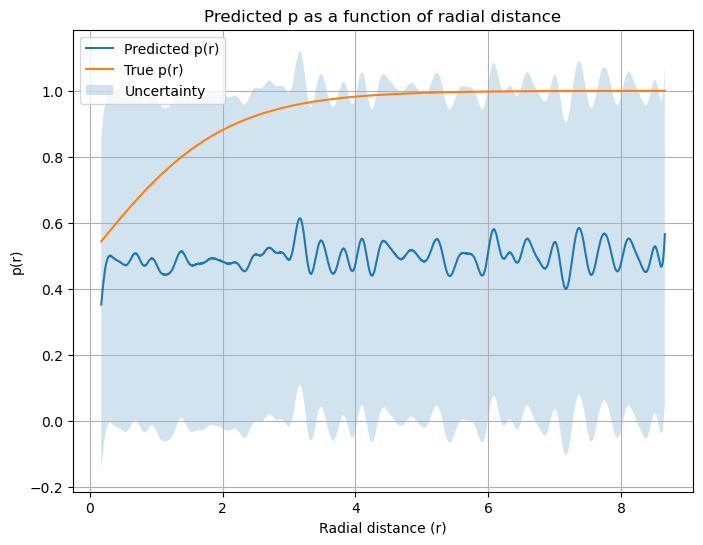

In [36]:
# Extract p values
p_pred = results.params["p_auto_loc"]
p_pred =  jax.nn.sigmoid(p_pred)
# Extract standard deviation for p
p_std = results.params["p_auto_scale"]
p_std =  jax.nn.sigmoid(p_std)
# Sort r and corresponding p values

# Plot p(r)
plt.figure(figsize=(8, 6))
plt.plot(r, p_pred, label="Predicted p(r)")
plt.plot(r,p, label="True p(r)")
plt.fill_between(r, p_pred - p_std, p_pred + p_std, alpha=0.2, label="Uncertainty")
plt.xlabel("Radial distance (r)")
plt.ylabel("p(r)")
plt.title("Predicted p as a function of radial distance")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
jnp.mean(p_pred)

Array(0.49580044, dtype=float32)

In [38]:
rho_true = rho(x, y, z, 0., p, 0.8, 1.0, 1.0, 1.0, 2.0)
rho_pred = rho(x, y, z, 0., p_pred, 0.8, 1.0, 1.0, 1.0, 2.0)

In [39]:
np.sum(rho_true)

Array(856.78766, dtype=float32)

In [40]:
np.sum(rho_true - rho_pred)

Array(-58.363056, dtype=float32)

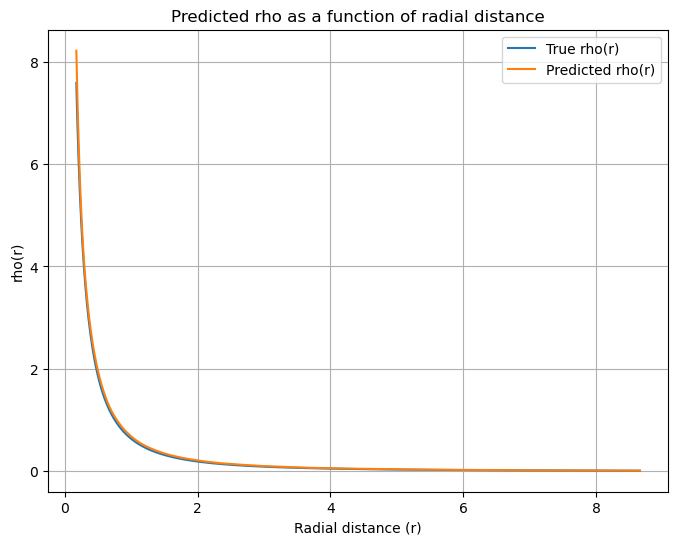

In [41]:
# Plot p(r)
plt.figure(figsize=(8, 6))
plt.plot(r,rho_true, label="True rho(r)")
plt.plot(r, rho_pred, label="Predicted rho(r)")

plt.xlabel("Radial distance (r)")
plt.ylabel("rho(r)")
plt.title("Predicted rho as a function of radial distance")
plt.legend()
plt.grid(True)
plt.show()